# LAB 4:  BÀI THỰC HÀNH CHUẨN BỊ DỮ LIỆU 
Nội dung: Chuẩn bị dữ liệu – Data Preparation 

Tham khảo: seaborn: statistical data visualization — seaborn 0.11.1 documentation (pydata.org) 

Mục tiêu: Sinh viên nắm được các kiến thức sau 

1. Data Cleansing 
2. Exploration Data Analysis (EDA) 
3. Kỹ thuật function chain trong Pandas – pipe() 
4. Feature Engineering 
5. Data Wrangling 
Mô tả dữ liệu: The sinking of the Titanic is one of the most infamous shipwrecks in history. On 
April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic 
sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone 
onboard, resulting in the death of 1502 out of 2224 passengers and crew. While there was some 
element of luck involved in surviving, it seems some groups of people were more likely to 
survive than others.

Yêu cầu: Hãy chuẩn bị dữ liệu phục vụ cho bài toán: “Xây dựng mô hình dự báo nhóm hành 
khách có khả năng sống sót với các thông số đầu vào là các đặc trưng của hành khách (name, 
age, gender, socio-economic class, …), trong sự kiện Titanic lịch sử” 
# PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

# 1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng đầu tiên.

In [ ]:
import pandas as pd

# Hàm load dữ liệu
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)   # Đọc file CSV
        return df
    except Exception as e:
        print("Lỗi khi load dữ liệu:", e)
        return None

# Gọi hàm và hiển thị 10 dòng đầu
data = load_data("titanic_disaster.csv")

if data is not None:
    print("10 dòng đầu của dữ liệu:")
    print(data.head(10))

# 2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 1. Load dữ liệu =====
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print("Lỗi:", e)
        return None

# ===== 2. Thống kê dữ liệu thiếu =====
def missing_data_stats(df):
    print("=== THỐNG KÊ DỮ LIỆU THIẾU ===")
    
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing Percent (%)': missing_percent
    })
    
    print(missing_df.sort_values(by='Missing Percent (%)', ascending=False))
    return missing_df

# ===== 3. Vẽ Heatmap =====
def plot_missing_heatmap(df):
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title("Heatmap dữ liệu thiếu")
    plt.xlabel("Biến")
    plt.ylabel("Quan sát")
    plt.show()

# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    print("\n10 dòng đầu:")
    print(data.head(10))
    
    # Thống kê thiếu
    missing_df = missing_data_stats(data)
    
    # Vẽ biểu đồ
    plot_missing_heatmap(data)

# 3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi tách cột xong thì xóa luôn cột Name 

In [ ]:
import pandas as pd

# ===== Load dữ liệu =====
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print("Lỗi:", e)
        return None

# ===== Tách cột Name =====
def split_name(df):
    # Titanic format: "LastName, Title. FirstName"
    
    # Tách theo dấu ","
    df[['last_part', 'first_part']] = df['Name'].str.split(',', expand=True)
    
    # Lấy firstName (sau dấu ".")
    df['firstName'] = df['first_part'].str.split('.').str[1].str.strip()
    
    # Lấy secondName (chính là họ)
    df['secondName'] = df['last_part'].str.strip()
    
    # Xóa các cột trung gian và Name
    df.drop(columns=['Name', 'last_part', 'first_part'], inplace=True)
    
    return df

# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = split_name(data)
    
    print("Sau khi tách cột Name:")
    print(data[['firstName', 'secondName']].head(10))

# 4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F

In [ ]:
import pandas as pd

# ===== FUNCTION =====
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print("Lỗi:", e)
        return None


def simplify_sex(df):
    # Thay thế giá trị
    df['Sex'] = df['Sex'].replace({
        'male': 'M',
        'female': 'F'
    })
    return df


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = simplify_sex(data)

    print("Sau khi rút gọn cột Sex:")
    print(data[['Sex']].head(10))

# 5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau 

a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def plot_age_by_pclass(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Pclass', y='Age', data=df)
    plt.title("Phân phối tuổi theo hạng vé (Pclass)")
    plt.xlabel("Pclass")
    plt.ylabel("Age")
    plt.show()


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    print("10 dòng đầu:")
    print(data.head(10))

    plot_age_by_pclass(data)

b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực 
quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map. 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def fill_age_by_pclass(df):
    age_mean = df.groupby('Pclass')['Age'].mean()

    print("\nTuổi trung bình theo Pclass:")
    print(age_mean)

    def fill_age(row):
        if pd.isnull(row['Age']):
            return age_mean[row['Pclass']]
        return row['Age']

    df['Age'] = df.apply(fill_age, axis=1)
    return df


def plot_heatmap_age(df):
    plt.figure(figsize=(10, 4))
    sns.heatmap(df[['Age']].isnull(), cbar=False, cmap='viridis')
    plt.title("Heatmap sau khi xử lý thiếu Age")
    plt.show()


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = fill_age_by_pclass(data)

    print("\nSau khi xử lý Age:")
    print(data[['Pclass', 'Age']].head(10))

    print("\nSố giá trị thiếu còn lại:", data['Age'].isnull().sum())

    plot_heatmap_age(data)

# 6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult và ( age > 60): Older 

In [ ]:
import pandas as pd

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def create_age_group(df):
    def classify_age(age):
        if age <= 12:
            return "Kid"
        elif age <= 18:
            return "Teen"
        elif age <= 60:
            return "Adult"
        else:
            return "Older"

    df['Agegroup'] = df['Age'].apply(classify_age)
    return df


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    # (Giả sử Age đã được xử lý missing ở bài 5)
    data = create_age_group(data)

    print("Kết quả tạo Agegroup:")
    print(data[['Age', 'Agegroup']].head(10))

# 7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách  Mr, Mrs, Miss, Master ra khỏi “secondName”

In [ ]:
import pandas as pd

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def extract_name_prefix(df):
    # Tách phần chứa title: "LastName, Title. FirstName"
    df['namePrefix'] = df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
    
    # Chỉ giữ các danh xưng phổ biến
    df['namePrefix'] = df['namePrefix'].replace({
        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Mrs'
    })

    return df


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = extract_name_prefix(data)

    print("Kết quả namePrefix:")
    print(data[['Name', 'namePrefix']].head(10))

# 8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch 

In [ ]:
import pandas as pd

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def create_family_size(df):
    # familySize = 1 + SibSp + Parch
    df['familySize'] = 1 + df['SibSp'] + df['Parch']
    return df


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = create_family_size(data)

    print("Kết quả familySize:")
    print(data[['SibSp', 'Parch', 'familySize']].head(10))

# 9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0. 

In [ ]:
import pandas as pd

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def create_family_size(df):
    # Bài 8 (nếu chưa có thì tạo luôn)
    df['familySize'] = 1 + df['SibSp'] + df['Parch']
    return df


def create_alone_feature(df):
    # Alone = 1 nếu familySize == 1 (đi 1 mình)
    # Alone = 0 nếu đi cùng người khác
    df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)
    return df


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = create_family_size(data)   # đảm bảo có familySize
    data = create_alone_feature(data)

    print("Kết quả Alone:")
    print(data[['familySize', 'Alone']].head(10))

# 10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu thì thay thế bằng “Unknown” 

In [ ]:
import pandas as pd

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def create_type_cabin(df):
    # Thay giá trị thiếu bằng 'Unknown'
    df['Cabin'] = df['Cabin'].fillna('Unknown')
    
    # Lấy chữ cái đầu tiên của cabin
    df['typeCabin'] = df['Cabin'].astype(str).str[0]
    
    return df


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = create_type_cabin(data)

    print("Kết quả typeCabin:")
    print(data[['Cabin', 'typeCabin']].head(10))

# PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA
Hướng dẫn: Sinh viên cần đưa ra nhận xét sau mỗi biểu đồ trực quan nhằm rút trích được 
thông tin có giá trị về hành khách sống sót dựa trên các đặc trưng bên trên 

# 12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def plot_survival_by_gender(df):
    # Tính tỉ lệ sống sót theo giới tính
    survival_rate = df.groupby('Sex')['Survived'].value_counts(normalize=True).unstack()

    # Vẽ biểu đồ
    survival_rate.plot(kind='bar')

    plt.title("Tỉ lệ sống sót và thiệt mạng theo giới tính")
    plt.xlabel("Giới tính")
    plt.ylabel("Tỉ lệ")
    plt.legend(["Thiệt mạng (0)", "Sống sót (1)"])
    plt.xticks(rotation=0)

    plt.show()


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    plot_survival_by_gender(data)

# 13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass). 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def plot_survival_by_pclass(df):
    # Đếm số lượng sống sót theo hạng vé
    survival_counts = df[df['Survived'] == 1]['Pclass'].value_counts().sort_index()

    # Vẽ biểu đồ
    survival_counts.plot(kind='bar')

    plt.title("Số hành khách sống sót theo hạng vé (Pclass)")
    plt.xlabel("Hạng vé (Pclass)")
    plt.ylabel("Số lượng sống sót")
    plt.xticks(rotation=0)

    plt.show()


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    plot_survival_by_pclass(data)

# 14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def create_age_group(df):
    # Tạo AgeGroup nếu chưa có
    def age_group(age):
        if pd.isna(age):
            return "Unknown"
        elif age <= 12:
            return "Kid"
        elif age <= 18:
            return "Teen"
        elif age <= 60:
            return "Adult"
        else:
            return "Older"
    
    df['AgeGroup'] = df['Age'].apply(age_group)
    return df


def plot_survival_by_sex_age(df):
    # Tính tỉ lệ sống
    survival_rate = df.groupby(['Sex', 'AgeGroup'])['Survived'].mean().unstack()

    # Vẽ biểu đồ
    survival_rate.plot(kind='bar')

    plt.title("Tỉ lệ sống sót theo Giới tính và Nhóm tuổi")
    plt.xlabel("Giới tính")
    plt.ylabel("Tỉ lệ sống")
    plt.xticks(rotation=0)

    plt.legend(title="AgeGroup")
    plt.show()


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = create_age_group(data)
    plot_survival_by_sex_age(data)

# 15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def create_family_features(df):
    # Tạo familySize
    df['familySize'] = 1 + df['SibSp'] + df['Parch']
    
    # Phân nhóm
    def family_group(size):
        if size == 1:
            return "Alone"
        elif size <= 4:
            return "Small"
        else:
            return "Large"
    
    df['familyGroup'] = df['familySize'].apply(family_group)
    return df


def plot_survival_by_family(df):
    # Tính xác suất sống (mean)
    survival_rate = df.groupby('familyGroup')['Survived'].mean()

    # Vẽ biểu đồ
    survival_rate.plot(kind='bar')

    plt.title("Xác suất sống sót theo nhóm đi cùng")
    plt.xlabel("Nhóm hành khách")
    plt.ylabel("Xác suất sống")
    plt.xticks(rotation=0)

    plt.show()


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = create_family_features(data)
    plot_survival_by_family(data)

# 16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def create_fare_group(df):
    # Chia nhóm giá vé
    df['FareGroup'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Mid', 'High', 'Very High'])
    return df


def plot_survival_by_fare(df):
    # Tính xác suất sống
    survival_rate = df.groupby('FareGroup', observed=True)['Survived'].mean()

    # Vẽ biểu đồ
    survival_rate.plot(kind='bar')

    plt.title("Xác suất sống sót theo nhóm giá vé")
    plt.xlabel("Nhóm giá vé")
    plt.ylabel("Xác suất sống")
    plt.xticks(rotation=0)

    plt.show()


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    data = create_fare_group(data)
    plot_survival_by_fare(data)

# 17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và cảng sẽ cập bến.

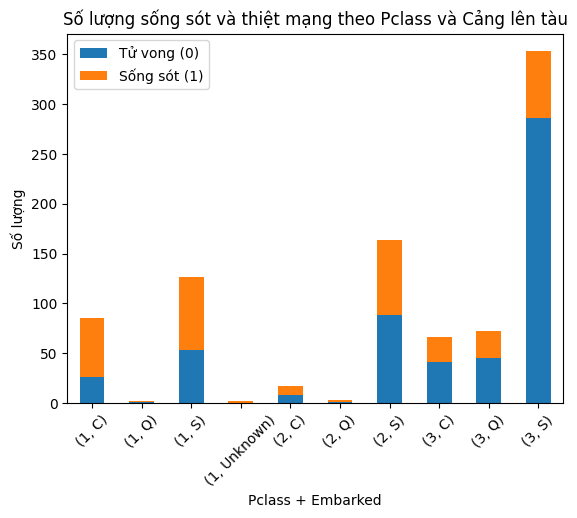

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== FUNCTION =====
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print("Lỗi:", e)
        return None


def plot_survival_pclass_embarked(df):
    # Thay giá trị thiếu của Embarked (nếu có)
    df['Embarked'] = df['Embarked'].fillna('Unknown')

    # Đếm số lượng theo 3 biến
    count_data = df.groupby(['Pclass', 'Embarked', 'Survived']).size().unstack(fill_value=0)

    # Vẽ biểu đồ (stacked bar)
    count_data.plot(kind='bar', stacked=True)

    plt.title("Số lượng sống sót và thiệt mạng theo Pclass và Cảng lên tàu")
    plt.xlabel("Pclass + Embarked")
    plt.ylabel("Số lượng")
    plt.xticks(rotation=45)

    plt.legend(["Tử vong (0)", "Sống sót (1)"])
    plt.show()


# ===== MAIN =====
data = load_data("titanic_disaster.csv")

if data is not None:
    plot_survival_pclass_embarked(data)